# 06 · LSTM Model — Multi-step Forecast

**Project:** War Shocks & Global Financial Risk Spillover  
**Hyperparameters:** loaded from `outputs/best_params_lstm.json` (selected by Optuna TPE, 30 trials)  
**Features:** 8 rolling vol + VIX_level + Brent_ret + Gold_ret (11 total)  
**Horizons:** h = 1, 5, 10, 22 (direct multi-output)  
**Ref:** Kumar et al. (2024); Akiba et al. (2019)

In [10]:
import sys, os, json
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import torch

from sklearn.preprocessing import MinMaxScaler
from src.data_loader import DATA_PROC_DIR
from src.var_models  import compute_metrics, compute_metrics_multistep, EQUITY_COLS, HORIZONS
from src.deep_models import (
    VolatilityRNN, train_model, predict,
    build_multistep_sequences, build_loaders,
    inverse_transform_vol, N_FEATURES, N_MARKETS,
    plot_forecast, plot_training_history,
)

SEED   = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

FIG_DIR   = os.path.join("..", "outputs", "figures")
TABLE_DIR = os.path.join("..", "outputs", "tables")
os.makedirs(FIG_DIR, exist_ok=True); os.makedirs(TABLE_DIR, exist_ok=True)

TRAIN_START = "2000-01-01"; TRAIN_END = "2018-12-31"
VAL_START   = "2019-01-01"; VAL_END   = "2021-12-31"
TEST_START  = "2022-01-01"; TEST_END  = "2025-12-31"

print(f"Device : {DEVICE}")

Device : cpu


## 1 · Load Best Hyperparameters

In [11]:
param_path = os.path.join("..", "outputs", "best_params_lstm.json")
with open(param_path) as f:
    best_params = json.load(f)

LOOKBACK    = best_params["lookback"]
HIDDEN_SIZE = best_params["hidden_size"]
N_LAYERS    = best_params["n_layers"]
DROPOUT     = best_params["dropout"]
LR          = best_params["lr"]
EPOCHS      = 50
PATIENCE    = 10
BATCH_SIZE  = 64

print(f"Best params from Optuna (nb05b):")
for k, v in best_params.items():
    print(f"  {k:15s}: {v}")

Best params from Optuna (nb05b):
  hidden_size    : 128
  n_layers       : 1
  dropout        : 0.3
  lr             : 0.01
  lookback       : 44


## 2 · Load & Build 11-Feature Matrix

In [ ]:
vol_df      = pd.read_excel(f"{DATA_PROC_DIR}/rolling_volatility.xlsx",
                 index_col=0, parse_dates=True)
war_df      = pd.read_excel(f"{DATA_PROC_DIR}/war_dummies.xlsx",
                 index_col=0, parse_dates=True)
all_vars    = pd.read_excel(f"{DATA_PROC_DIR}/all_variables_aligned.xlsx",
                 index_col=0, parse_dates=True)
spill_df    = pd.read_excel(f"{DATA_PROC_DIR}/spillover_index.xlsx",
                 index_col=0, parse_dates=True)

controls = all_vars[["VIX", "Brent", "Gold"]].copy()
controls["Gold_ret"]  = np.log(controls["Gold"]  / controls["Gold"].shift(1))
controls["Brent_ret"] = np.log(controls["Brent"] / controls["Brent"].shift(1))
controls["VIX_level"] = controls["VIX"]
exog = controls[["VIX_level", "Brent_ret", "Gold_ret"]].shift(1)

# Net spillover per market (lag-1 to avoid look-ahead bias)
# Columns: net_SP500, net_DAX, net_CAC40, net_FTSE100,
#          net_Nikkei, net_KOSPI, net_HangSeng, net_SSE
net_cols  = [c for c in spill_df.columns if c.startswith("net_")]
spill_feat = spill_df[net_cols].shift(1)

common_idx  = vol_df.dropna().index
vol_clean   = vol_df.loc[common_idx, EQUITY_COLS]
exog_clean  = exog.reindex(common_idx).ffill(limit=3)
spill_clean = spill_feat.reindex(common_idx).ffill(limit=5)

valid_mask  = (exog_clean.notna().all(axis=1)
               & spill_clean.notna().all(axis=1))
vol_clean   = vol_clean[valid_mask]
exog_clean  = exog_clean[valid_mask]
spill_clean = spill_clean[valid_mask]
features_df = pd.concat([vol_clean, exog_clean, spill_clean], axis=1)

# 8 vol + 3 controls + 8 net spillover = 19
assert features_df.shape[1] == N_FEATURES, (
    f"Expected {N_FEATURES} features, got {features_df.shape[1]}\n"
    f"Columns: {list(features_df.columns)}")
print(f"features_df : {features_df.shape}")
print(f"Columns     : {list(features_df.columns)}")
print(f"Date range  : {features_df.index[0].date()} ~ {features_df.index[-1].date()}")

features_df : (4879, 19)
Columns     : ['SP500_vol', 'DAX_vol', 'CAC40_vol', 'FTSE100_vol', 'Nikkei_vol', 'KOSPI_vol', 'HangSeng_vol', 'SSE_vol', 'VIX_level', 'Brent_ret', 'Gold_ret', 'net_SP500', 'net_DAX', 'net_CAC40', 'net_FTSE100', 'net_Nikkei', 'net_KOSPI', 'net_HangSeng', 'net_SSE']
Date range  : 2001-04-18 ~ 2025-12-30


## 3 · Split & Scale

In [13]:
feat_train = features_df.loc[TRAIN_START:TRAIN_END].values
feat_val   = features_df.loc[VAL_START:VAL_END].values
feat_test  = features_df.loc[TEST_START:TEST_END].values
val_dates  = features_df.loc[VAL_START:VAL_END].index
test_dates = features_df.loc[TEST_START:TEST_END].index

scaler = MinMaxScaler(feature_range=(0, 1))
feat_train_scaled = scaler.fit_transform(feat_train)
feat_val_scaled   = scaler.transform(feat_val)
feat_test_scaled  = scaler.transform(feat_test)

print(f"Train: {feat_train_scaled.shape}")
print(f"Val  : {feat_val_scaled.shape}")
print(f"Test : {feat_test_scaled.shape}")

Train: (3474, 19)
Val  : (594, 19)
Test : (811, 19)


## 4 · Build Multi-step Sequences

Direct multi-output: for each origin t, targets are vol at t+h for each h.  
Model is trained separately for each horizon h (direct strategy avoids  
error accumulation in recursive multi-step forecasting).

Building sequences for h=1 ...
  Training h=1 ...
  h=1: best_epoch=28  best_val_loss=0.000583
Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig_training_history_lstm_h1.png


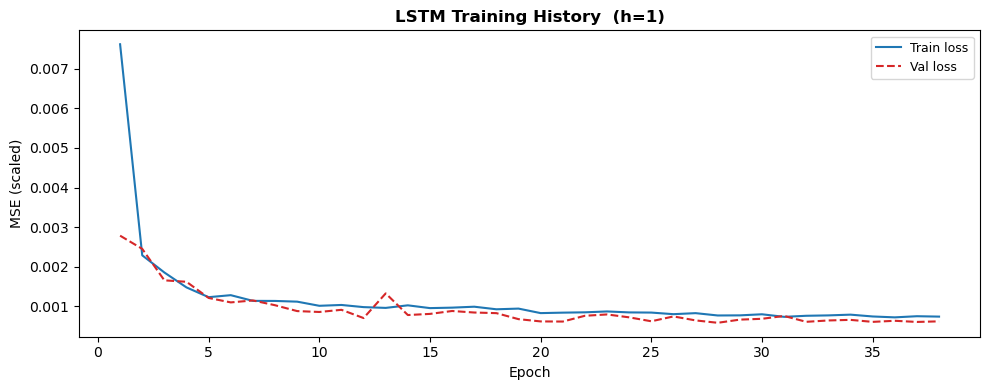

Building sequences for h=5 ...
  Training h=5 ...
  h=5: best_epoch=13  best_val_loss=0.003084
Building sequences for h=10 ...
  Training h=10 ...
  h=10: best_epoch=13  best_val_loss=0.006792
Building sequences for h=22 ...
  Training h=22 ...
  h=22: best_epoch=6  best_val_loss=0.020032

All horizons trained.


In [14]:
results_val_ms  = {}
results_test_ms = {}

for h in HORIZONS:
    print(f"Building sequences for h={h} ...")
    X_tr, Y_tr_dict, _ = build_multistep_sequences(
        feat_train_scaled, lookback=LOOKBACK, horizons=[h])
    X_vl, Y_vl_dict, vi = build_multistep_sequences(
        feat_val_scaled,   lookback=LOOKBACK, horizons=[h])
    X_te, Y_te_dict, ti = build_multistep_sequences(
        feat_test_scaled,  lookback=LOOKBACK, horizons=[h])

    y_tr = Y_tr_dict[h]; y_vl = Y_vl_dict[h]; y_te = Y_te_dict[h]
    val_seq_dates  = val_dates[vi]
    test_seq_dates = test_dates[ti]

    tr_ldr, vl_ldr = build_loaders(X_tr, y_tr, X_vl, y_vl, batch_size=BATCH_SIZE)

    # Initialise fresh model for each horizon
    model_h = VolatilityRNN("LSTM",
        n_features=N_FEATURES, hidden_size=HIDDEN_SIZE,
        n_layers=N_LAYERS, dropout=DROPOUT, n_outputs=N_MARKETS
    ).to(DEVICE)

    print(f"  Training h={h} ...")
    model_h, history_h, best_ep_h = train_model(
        model_h, tr_ldr, vl_ldr,
        epochs=EPOCHS, lr=LR, patience=PATIENCE,
        device=DEVICE, verbose=False
    )
    print(f"  h={h}: best_epoch={best_ep_h}  "
          f"best_val_loss={min(history_h['val_loss']):.6f}")

    # Forecasts
    preds_vl = predict(model_h, X_vl, DEVICE)
    preds_te = predict(model_h, X_te, DEVICE)

    fc_val  = pd.DataFrame(inverse_transform_vol(preds_vl, scaler),
                            index=val_seq_dates,  columns=EQUITY_COLS)
    act_val = pd.DataFrame(inverse_transform_vol(y_vl, scaler),
                            index=val_seq_dates,  columns=EQUITY_COLS)
    fc_test  = pd.DataFrame(inverse_transform_vol(preds_te, scaler),
                             index=test_seq_dates, columns=EQUITY_COLS)
    act_test = pd.DataFrame(inverse_transform_vol(y_te, scaler),
                             index=test_seq_dates, columns=EQUITY_COLS)

    results_val_ms[h]  = (act_val,  fc_val)
    results_test_ms[h] = (act_test, fc_test)

    # Save weights for largest model (h=1 is reference)
    if h == 1:
        plot_training_history(history_h, model_name="LSTM", horizon=1)
        torch.save(model_h.state_dict(),
                   os.path.join("..", "outputs", "lstm_best_weights.pt"))

print("\nAll horizons trained.")

## 5 · Evaluation Metrics

In [15]:
metrics_val  = compute_metrics_multistep(results_val_ms,  label="LSTM_Val")
metrics_test = compute_metrics_multistep(results_test_ms, label="LSTM_Test")

print("=" * 65)
print("LSTM METRICS — Validation (AVERAGE across markets)")
print("=" * 65)
for h in HORIZONS:
    sub = metrics_val[(metrics_val["Horizon"]==h) & (metrics_val["Market"]=="AVERAGE")].iloc[0]
    print(f"  h={h:2d}: MSE={sub['MSE']:.6f}  MAE={sub['MAE']:.4f}  "
          f"RMSE={sub['RMSE']:.4f}  MAPE={sub['MAPE']:.2f}%  DirAcc={sub['Dir_Acc']:.3f}")

print("\n" + "=" * 65)
print("LSTM METRICS — Test (AVERAGE across markets)")
print("=" * 65)
for h in HORIZONS:
    sub = metrics_test[(metrics_test["Horizon"]==h) & (metrics_test["Market"]=="AVERAGE")].iloc[0]
    print(f"  h={h:2d}: MSE={sub['MSE']:.6f}  MAE={sub['MAE']:.4f}  "
          f"RMSE={sub['RMSE']:.4f}  MAPE={sub['MAPE']:.2f}%  DirAcc={sub['Dir_Acc']:.3f}")

LSTM METRICS — Validation (AVERAGE across markets)
  h= 1: MSE=0.000378  MAE=0.0112  RMSE=0.0192  MAPE=6.59%  DirAcc=0.540
  h= 5: MSE=0.001956  MAE=0.0296  RMSE=0.0437  MAPE=17.96%  DirAcc=0.481
  h=10: MSE=0.004202  MAE=0.0436  RMSE=0.0635  MAPE=27.18%  DirAcc=0.488
  h=22: MSE=0.012389  MAE=0.0651  RMSE=0.1074  MAPE=36.23%  DirAcc=0.491

LSTM METRICS — Test (AVERAGE across markets)
  h= 1: MSE=0.000291  MAE=0.0099  RMSE=0.0166  MAPE=6.65%  DirAcc=0.529
  h= 5: MSE=0.001986  MAE=0.0290  RMSE=0.0434  MAPE=18.95%  DirAcc=0.511
  h=10: MSE=0.003714  MAE=0.0410  RMSE=0.0587  MAPE=26.28%  DirAcc=0.508
  h=22: MSE=0.006553  MAE=0.0555  RMSE=0.0789  MAPE=36.79%  DirAcc=0.522


## 6 · Regime Breakdown (Val, h=1)

In [ ]:
act_h1, fc_h1 = results_val_ms[1]
war_val    = war_df["mideast_war"].reindex(act_h1.index).fillna(0).astype(int)
crisis_val = war_df["any_crisis"].reindex(act_h1.index).fillna(0).astype(int)

# Regime breakdown — no Soleimani exclusion (US-Iran crisis only 6 days)
regime_masks = {
    "B: War-Only"   : (war_val==1) & (crisis_val==0),
    "C: Crisis-Only": (war_val==0) & (crisis_val==1),
    "D: War+Crisis" : (war_val==1) & (crisis_val==1),
}

print("=" * 65)
print("LSTM CONDITIONAL METRICS — Val h=1 by Regime")
print("=" * 65)

regime_results = {}
for name, mask in regime_masks.items():
    n = mask.sum()
    if n < 10:
        print(f"  {name}: {n} obs — skip"); continue
    m   = compute_metrics(act_h1[mask], fc_h1[mask], label=name)
    avg = m[m["Market"]=="AVERAGE"].iloc[0]
    print(f"  {name:25s} (n={n:4d}): "
          f"MSE={avg['MSE']:.6f}  RMSE={avg['RMSE']:.6f}  MAPE={avg['MAPE']:.2f}%")
    regime_results[name] = m

LSTM CONDITIONAL METRICS — Val h=1 by Regime
  B: War-Only: 4 obs — skip
  C: Crisis-Only            (n= 147): MSE=0.000962  RMSE=0.030565  MAPE=6.86%
  D: War+Crisis: 0 obs — skip


## 7 · Save Results

In [17]:
for h in HORIZONS:
    sub_val  = metrics_val[metrics_val["Horizon"]==h]
    sub_test = metrics_test[metrics_test["Horizon"]==h]
    pd.concat([sub_val, sub_test], ignore_index=True).to_excel(
        os.path.join(TABLE_DIR, f"table_lstm_metrics_h{h}.xlsx"), index=False)

act_h1, fc_h1   = results_val_ms[1]
act_t1, fc_t1   = results_test_ms[1]
act_h1.to_excel(os.path.join(TABLE_DIR, "lstm_actual_val.xlsx"))
fc_h1.to_excel(os.path.join(TABLE_DIR,  "lstm_forecast_val.xlsx"))
act_t1.to_excel(os.path.join(TABLE_DIR, "lstm_actual_test.xlsx"))
fc_t1.to_excel(os.path.join(TABLE_DIR,  "lstm_forecast_test.xlsx"))
print(f"Saved all LSTM metrics and forecasts.")

Saved all LSTM metrics and forecasts.


## 8 · Fig 12 · LSTM Forecast vs Actual (h=1)

Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig10_lstm_forecast.png


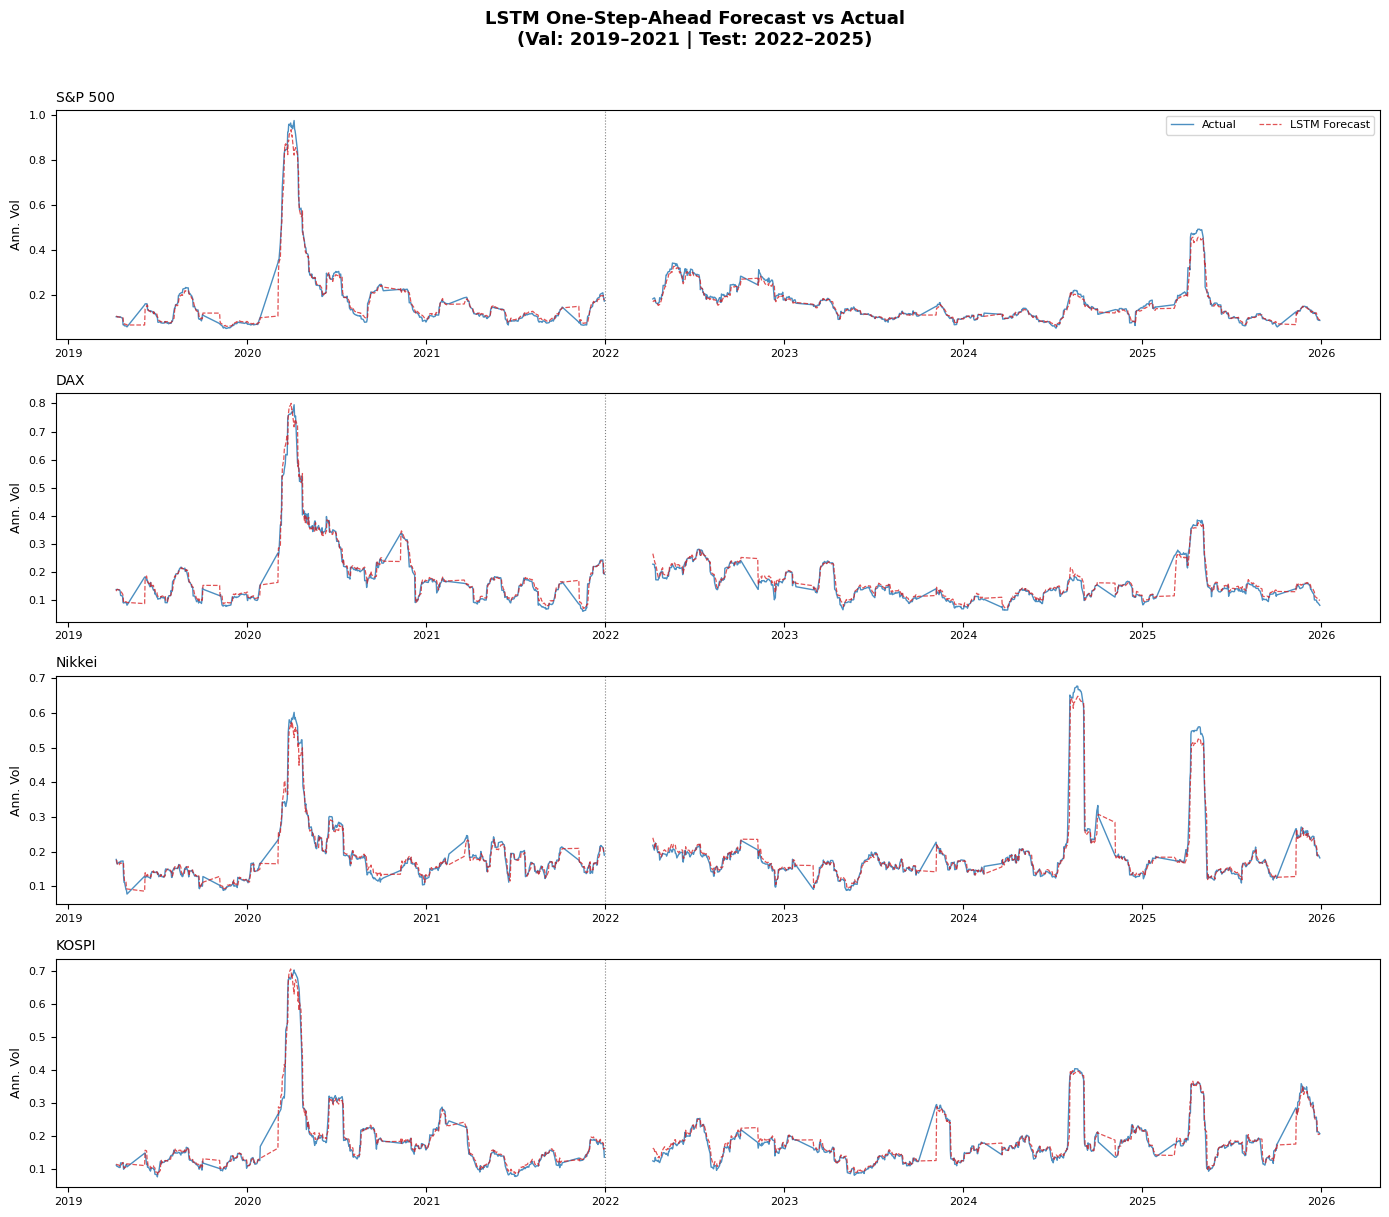

In [ ]:
plot_forecast(
    results_val_ms, results_test_ms,
    test_start=TEST_START,
    model_name="LSTM",
    fig_filename="fig12_lstm_forecast.png",
    forecast_color="#d7191c",
)

---
**Next → 07_gru_model.ipynb**